# Clean Card Detection Pipeline

This notebook keeps the workflow readable. The detection logic lives in `card_detection/`, while the notebook chooses inputs, optionally tunes thresholds, and displays results.

In [1]:
from pathlib import Path

from card_detection import (
    DEFAULT_COLORS,
    CardDetectionPaths,
    create_threshold_tuner,
    detect_cards_in_image,
    load_card_template,
    load_color_thresholds,
    load_gray_threshold,
    load_image,
    load_rectangle_settings,
    load_threshold_rectangle_settings,
    parse_hsv_file,
    show_detection_result,
    show_images,
    train_images,
)


## Inputs

Choose the image and the color used by the optional tuner. The all-color detector uses the saved threshold files for every color.

Image: L1000983.jpg
Detection colors: ('blue', 'red', 'yellow', 'black', 'green')
Rectangle settings: {'min_area': 4000, 'close_size': 2, 'close_iter': 10, 'min_fill': 10, 'min_score': 0, 'angle_step': 2, 'max_outside': 10}


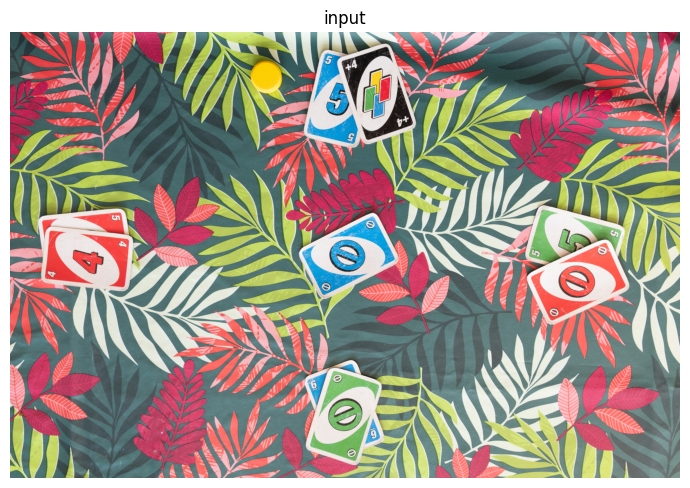

In [2]:
BASE_DIR = Path.cwd()
PATHS = CardDetectionPaths(BASE_DIR)

IMAGE_NAME = "L1000983.jpg"
TUNER_COLOR = "black"
DETECTION_COLORS = DEFAULT_COLORS  # Use (TUNER_COLOR,) to compare the final detector with the tuner color only.
SCALE = 0.25

image_path = PATHS.train_dir / IMAGE_NAME
if not image_path.exists():
    available_images = train_images(PATHS.train_dir)
    if not available_images:
        raise FileNotFoundError(f"No training images found in {PATHS.train_dir}")
    image_path = available_images[0]

image_bgr, image_rgb = load_image(image_path)
card_template_mask = load_card_template(PATHS.card_template_mask)
color_thresholds = load_color_thresholds(PATHS, DEFAULT_COLORS)
rectangle_defaults = load_rectangle_settings(PATHS.rectangle_settings)
rectangle_settings = load_threshold_rectangle_settings(PATHS.threshold_rectangle_settings, rectangle_defaults)

print("Image:", image_path.name)
print("Detection colors:", DETECTION_COLORS)
print("Rectangle settings:", rectangle_settings)
show_images([("input", image_rgb)], cols=1, figsize=(7, 7))


## Optional Tuner

Set `RUN_TUNER = True` to open the threshold and rectangle controls. Saving updates the same text files used by the detector.

In [3]:
RUN_TUNER = False  

if RUN_TUNER:
    use_gray = TUNER_COLOR == "black" and PATHS.gray_file(TUNER_COLOR).exists()
    hsv_ranges = [] if use_gray else parse_hsv_file(PATHS.hsv_file(TUNER_COLOR))
    gray_settings = load_gray_threshold(PATHS.gray_file(TUNER_COLOR))

    tuner = create_threshold_tuner(
        image_bgr=image_bgr,
        image_rgb=image_rgb,
        color=TUNER_COLOR,
        hsv_ranges=hsv_ranges,
        gray_settings=gray_settings,
        rectangle_settings=rectangle_settings,
        card_template_mask=card_template_mask,
        hsv_path=PATHS.hsv_file(TUNER_COLOR),
        gray_path=PATHS.gray_file(TUNER_COLOR),
        rectangle_settings_path=PATHS.threshold_rectangle_settings,
        use_gray_threshold=use_gray,
        scale=SCALE,
    )


## Detect Cards

The final detector reloads saved threshold files first. If you tuned sliders but did not press save, those unsaved widget values are only visible in the tuner preview.

Each color is fitted independently. Scores are only used to order candidates within the same color, so a candidate from one color cannot suppress a candidate from another color.


In [4]:
color_thresholds = load_color_thresholds(PATHS, DEFAULT_COLORS)
rectangle_defaults = load_rectangle_settings(PATHS.rectangle_settings)
rectangle_settings = load_threshold_rectangle_settings(PATHS.threshold_rectangle_settings, rectangle_defaults)

result = detect_cards_in_image(
    image_bgr=image_bgr,
    image_rgb=image_rgb,
    color_thresholds=color_thresholds,
    rectangle_settings=rectangle_settings,
    card_template_mask=card_template_mask,
    colors=DETECTION_COLORS,
    scale=SCALE,
)

print("Detection colors:", DETECTION_COLORS)
print("Rectangle settings:", rectangle_settings)
print(f"Detected cards: {len(result.cards)}")
for row in result.rows:
    kind = row.get("kind", "card")
    print(f"#{row['rank']}: {kind} {row['color']} score={row['score']:.1f} fill={row['fill']:.2f} bbox={row['bbox']}")


Detection colors: ('blue', 'red', 'yellow', 'black', 'green')
Rectangle settings: {'min_area': 4000, 'close_size': 2, 'close_iter': 10, 'min_fill': 10, 'min_score': 0, 'angle_step': 2, 'max_outside': 10}
Detected cards: 10
#1: card blue score=2664.4 fill=0.78 bbox=(432, 272, 145, 122)
#2: card blue score=1733.2 fill=0.63 bbox=(441, 29, 103, 140)
#3: card blue score=178.8 fill=0.20 bbox=(441, 492, 113, 143)
#4: card red score=2636.2 fill=0.78 bbox=(47, 293, 134, 91)
#5: card red score=2407.7 fill=0.74 bbox=(776, 312, 144, 119)
#6: card red score=321.5 fill=0.27 bbox=(42, 265, 134, 91)
#7: card yellow score=362.2 fill=0.29 bbox=(357, 9, 145, 125)
#8: card black score=1579.0 fill=0.60 bbox=(493, 20, 109, 142)
#9: card green score=2517.2 fill=0.76 bbox=(444, 500, 110, 142)
#10: card green score=1628.4 fill=0.61 bbox=(773, 263, 140, 106)


## Result

The debug masks show each color threshold after cleanup. The overlay shows accepted detections, and the final grid shows extracted cards.

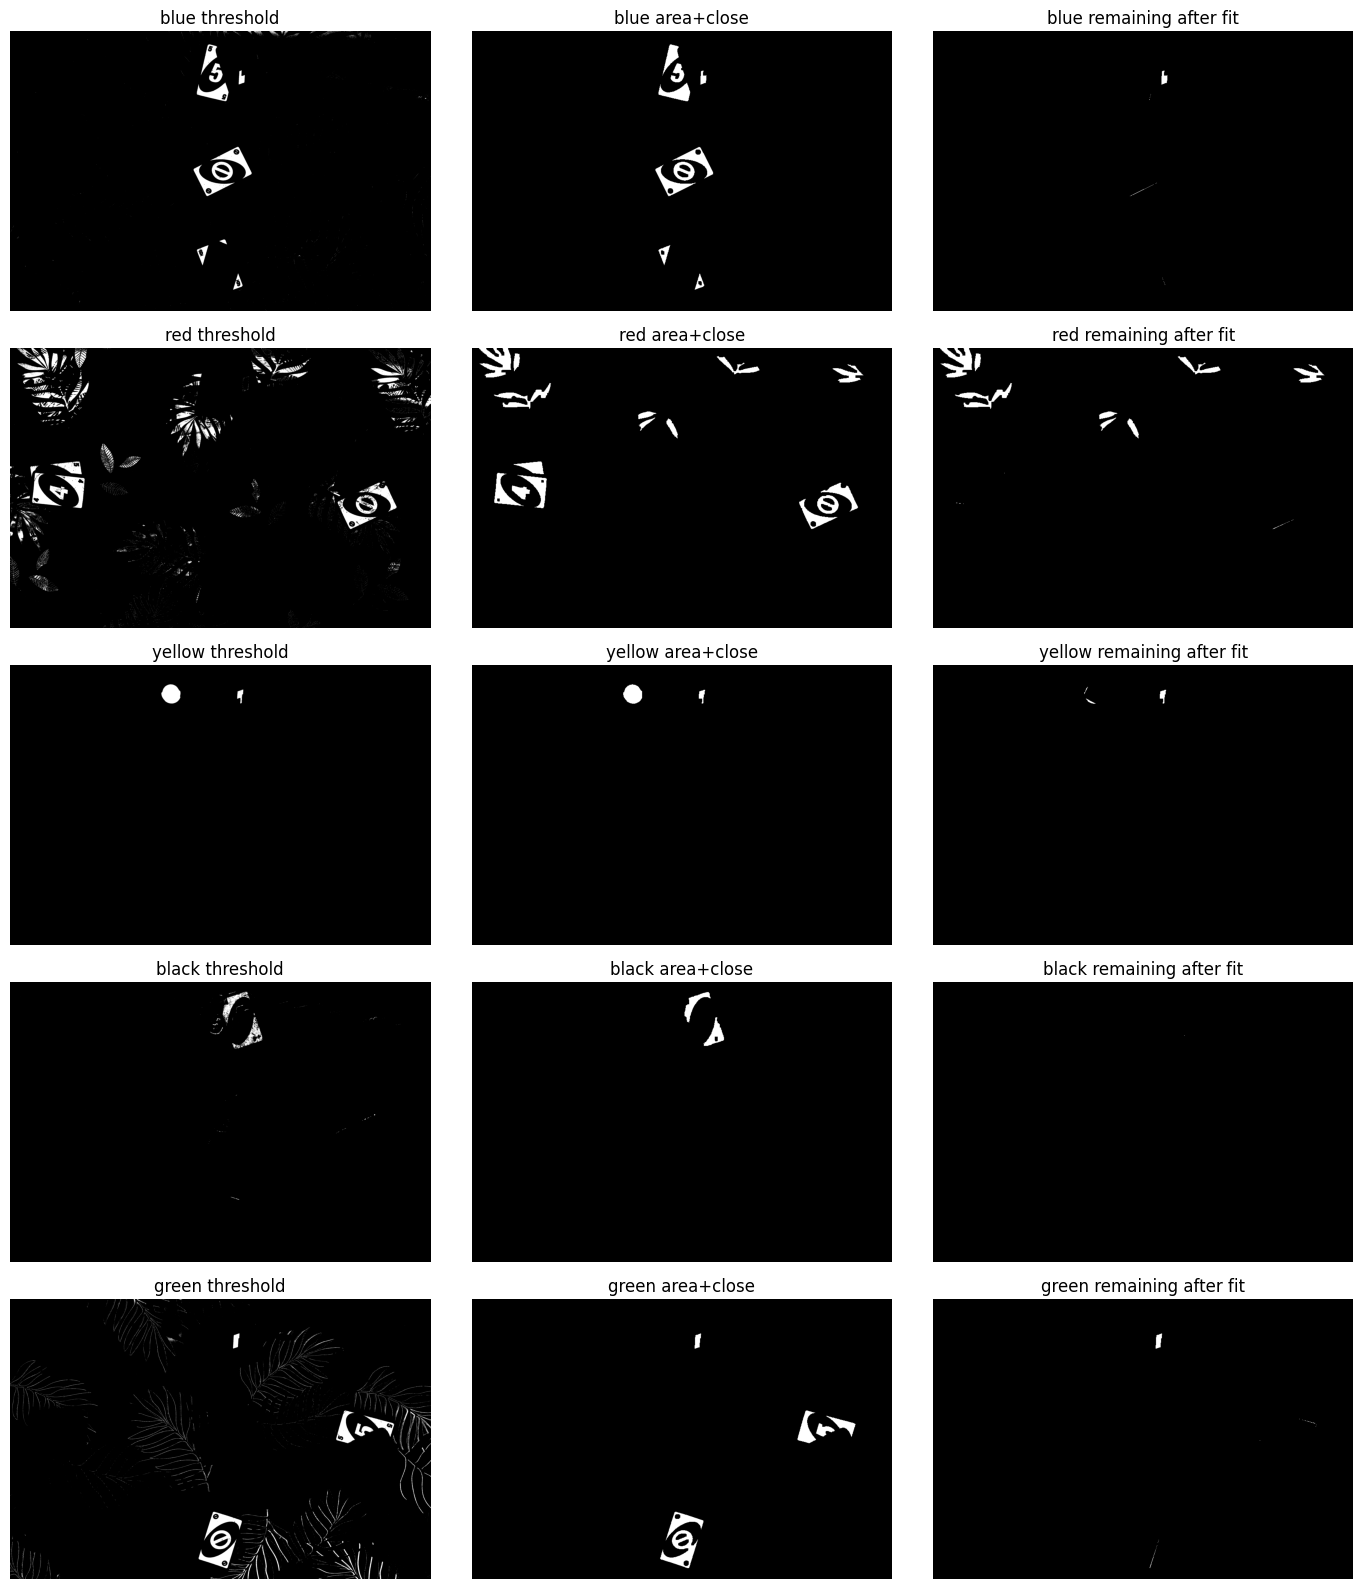

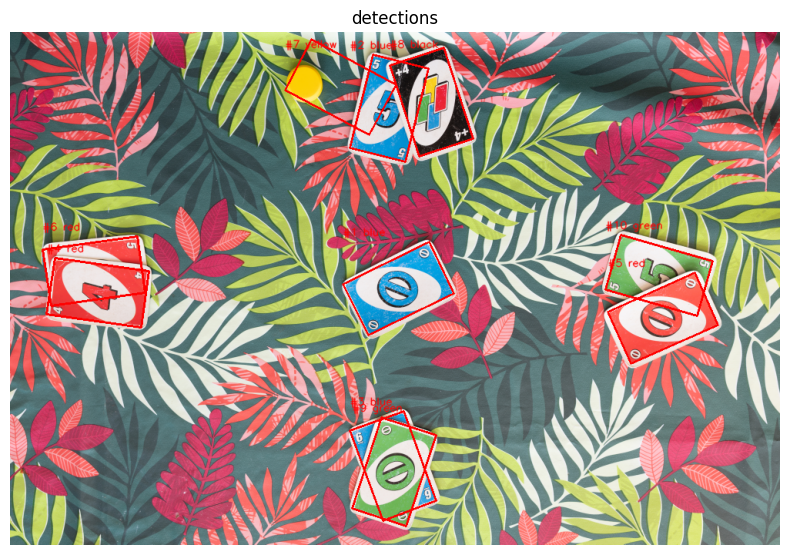

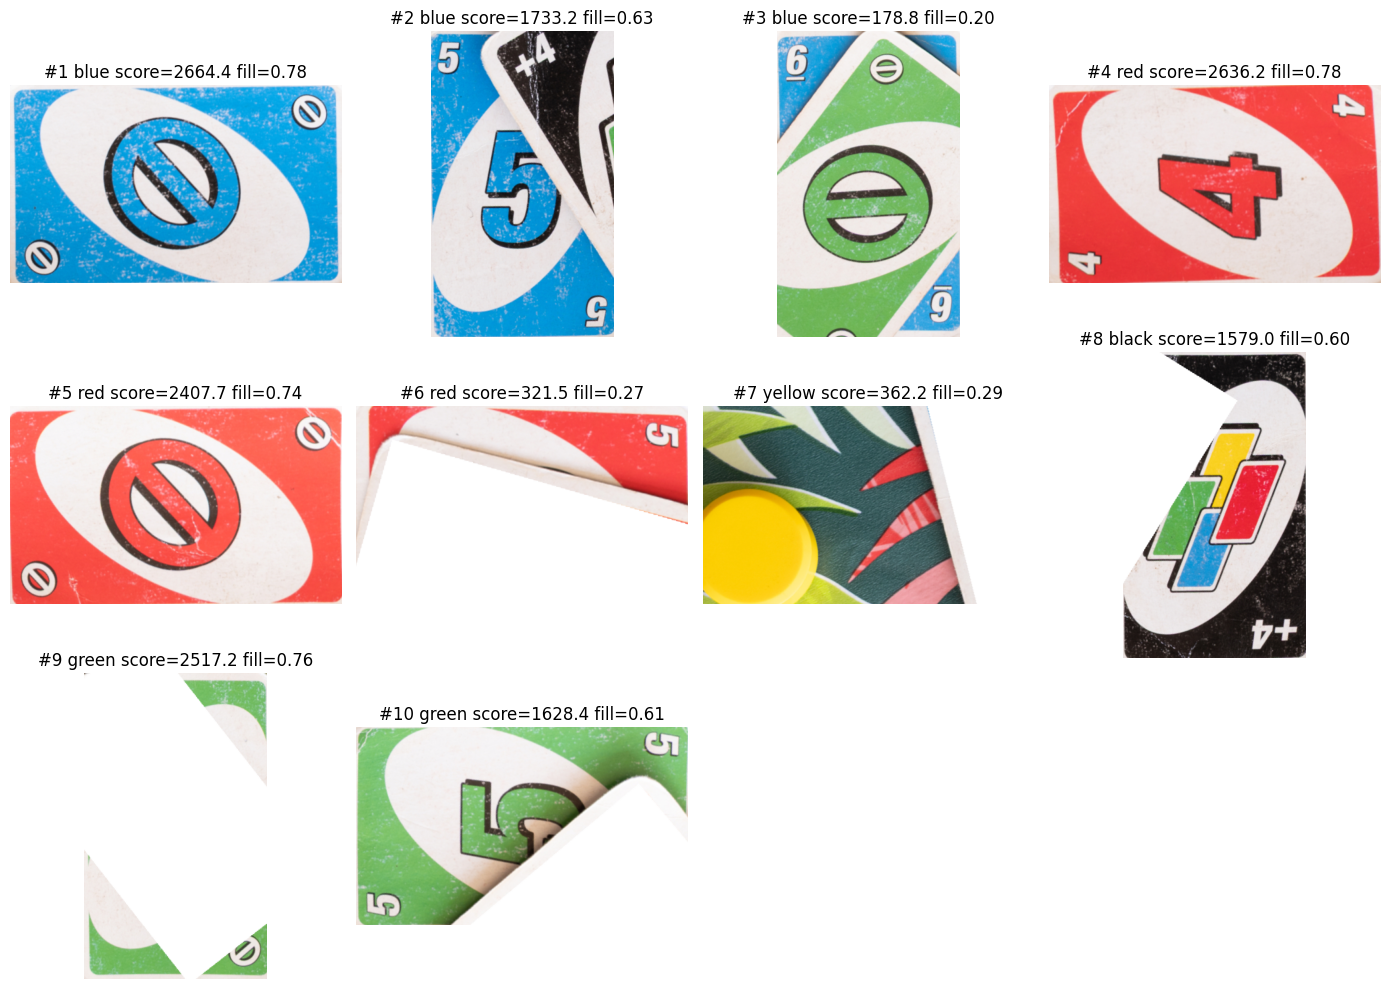

In [5]:
show_detection_result(result)
